In [1]:
# Cell 1 - Imports and Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add src/ to path to use project config
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.insert(0, '../src')
from config import (
    MOLECULES, N_MOLECULES, RANDOM_SEED, STRONG_FEATURES,
    WEAK_FEATURES, BIOSIGNATURES, LOG_VMR_MIN, LOG_VMR_MAX,
    TRAIN_FRAC, VAL_FRAC, TEST_FRAC
)

print("All libraries loaded ✓")
print(f"Molecules: {MOLECULES}")

All libraries loaded ✓
Molecules: ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']


In [2]:
# Cell 2 - Load Data from inara_data/
DATA_DIR = os.path.join('..', 'inara_data')

spectra     = np.load(os.path.join(DATA_DIR, 'spectra.npy'))
molecules   = np.load(os.path.join(DATA_DIR, 'molecules.npy'))
aux_params  = np.load(os.path.join(DATA_DIR, 'aux_params.npy'))
wavelengths = np.load(os.path.join(DATA_DIR, 'wavelengths.npy'))
params_df   = pd.read_csv(os.path.join(DATA_DIR, 'parameters_processed.csv'))

print(f"Spectra shape:     {spectra.shape}")
print(f"Molecules shape:   {molecules.shape}")
print(f"Aux params shape:  {aux_params.shape}")
print(f"Wavelengths shape: {wavelengths.shape}")
print(f"Params df shape:   {params_df.shape}")
print(f"\nInput channels:")
print(f"  Ch0 - Normalised SNR:    {spectra[:,0,:].shape}")
print(f"  Ch1 - Mean Subtracted:   {spectra[:,1,:].shape}")
print(f"  Ch2 - Log Transit Depth: {spectra[:,2,:].shape}")

Spectra shape:     (214, 3, 4378)
Molecules shape:   (214, 12)
Aux params shape:  (214, 8)
Wavelengths shape: (4378,)
Params df shape:   (214, 21)

Input channels:
  Ch0 - Normalised SNR:    (214, 4378)
  Ch1 - Mean Subtracted:   (214, 4378)
  Ch2 - Log Transit Depth: (214, 4378)


In [ ]:
# Cell 3 - Generated demo data 
from download_inara import generate_demo

PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

# Generating  samples 
print("Generating 20,000 synthetic samples...")
generate_demo(output_dir=PROCESSED_DIR, n_samples=20000)
print("Done ✓")

21:57:42  Generating 20,000 synthetic samples (demo mode)...


Generating 20,000 synthetic samples...


21:57:53  Saved to ../inara_data/processed:
21:57:53    spectra.npy     (20000, 3, 4378)
21:57:53    molecules.npy   (20000, 12)
21:57:53    aux_params.npy  (20000, 8)



  Molecule     Mean     Std     Min     Max
  --------------------------------------------
  H2O         -3.01    1.48   -8.00    0.00
  CO2         -3.50    1.49   -8.00    0.00
  O2          -4.02    1.48   -8.00    0.00
  O3          -6.47    0.95   -8.00   -2.47
  CH4         -5.01    1.48   -8.00    0.00
  N2          -1.04    0.73   -4.05    0.00
  N2O         -6.47    0.95   -8.00   -1.91
  CO          -5.47    1.44   -8.00    0.00
  H2          -4.47    1.48   -8.00    0.00
  H2S         -5.98    1.15   -8.00   -0.01
  SO2         -6.44    1.08   -8.00   -1.59
  NH3         -5.93    1.38   -8.00    0.00
Done ✓


In [ ]:
# Cell 4 - Loading dataset
PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

spectra_full    = np.load(os.path.join(PROCESSED_DIR, 'spectra.npy'))
molecules_full  = np.load(os.path.join(PROCESSED_DIR, 'molecules.npy'))
aux_full        = np.load(os.path.join(PROCESSED_DIR, 'aux_params.npy'))
wavelengths_full= np.load(os.path.join(PROCESSED_DIR, 'wavelengths.npy'))

print(f"Full dataset:")
print(f"  Spectra shape:    {spectra_full.shape}")
print(f"  Molecules shape:  {molecules_full.shape}")
print(f"  Aux shape:        {aux_full.shape}")
print(f"  NaN in molecules: {np.isnan(molecules_full).sum()}")

Full dataset:
  Spectra shape:    (20000, 3, 4378)
  Molecules shape:  (20000, 12)
  Aux shape:        (20000, 8)
  NaN in molecules: 0


In [ ]:
# Cell 5 - Prepare Features and Split Data
# Use Ch0 (normalised SNR) and Ch1 (mean-subtracted) as features

snr_ch   = spectra_full[:, 0, :]  # (20000, 4378)
meansub  = spectra_full[:, 1, :]  # (20000, 4378)

# Combine spectral channels + auxiliary features
X_spec = np.hstack([snr_ch, meansub])          # (20000, 8756)
X_full = np.hstack([X_spec, aux_full])          # (20000, 8764)
y_full = molecules_full                         # (20000, 12)

# Train/Val/Test split matching config.py ratios
# 70% train, 15% val, 15% test
rng  = np.random.default_rng(RANDOM_SEED)
idx  = rng.permutation(len(X_full))
n_train = int(len(X_full) * TRAIN_FRAC)
n_val   = int(len(X_full) * VAL_FRAC)

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

X_train, y_train = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]
X_test,  y_test  = X_full[test_idx],  y_full[test_idx]

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Val:   {X_val.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

Train: 14,000 samples
Val:   3,000 samples
Test:  3,000 samples
Features: 8764


In [ ]:
# Cell 6 - Train Random Forest Baseline

print("Training Random Forest Baseline...")
print("This may take 2-3 minutes...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)
print("\nTraining complete ✓")

Training Random Forest Baseline...
This may take 2-3 minutes...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 18.0min



Training complete ✓


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 43.9min finished


In [7]:
# Cell 7 - Evaluate Random Forest on Test Set
y_pred = rf_model.predict(X_test)

print("="*60)
print("Random Forest Baseline — Per Molecule Results")
print("="*60)
print(f"{'Molecule':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'Difficulty'}")
print("-"*60)

rmse_list, mae_list, r2_list = [], [], []

for i, mol in enumerate(MOLECULES):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    
    if mol in STRONG_FEATURES:
        diff = 'Easy'
    elif mol in WEAK_FEATURES:
        diff = 'Hard'
    else:
        diff = 'Medium'
    
    print(f"{mol:<8} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}  {diff}")

print("-"*60)
print(f"{'MEAN':<8} {np.mean(rmse_list):>8.3f} {np.mean(mae_list):>8.3f} {np.mean(r2_list):>8.3f}")
print("="*60)

Random Forest Baseline — Per Molecule Results
Molecule     RMSE      MAE       R2 Difficulty
------------------------------------------------------------
H2O         0.886    0.711    0.627  Easy
CO2         1.386    1.105    0.081  Easy
O2          0.957    0.757    0.577  Easy
O3          0.891    0.731    0.089  Easy
CH4         1.328    1.068    0.192  Medium
N2          0.738    0.612   -0.007  Hard
N2O         0.955    0.776   -0.001  Medium
CO          1.433    1.154    0.007  Medium
H2          1.456    1.161   -0.005  Hard
H2S         1.146    0.933   -0.002  Medium
SO2         1.084    0.887   -0.014  Medium
NH3         1.396    1.145   -0.007  Medium
------------------------------------------------------------
MEAN        1.138    0.920    0.128


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


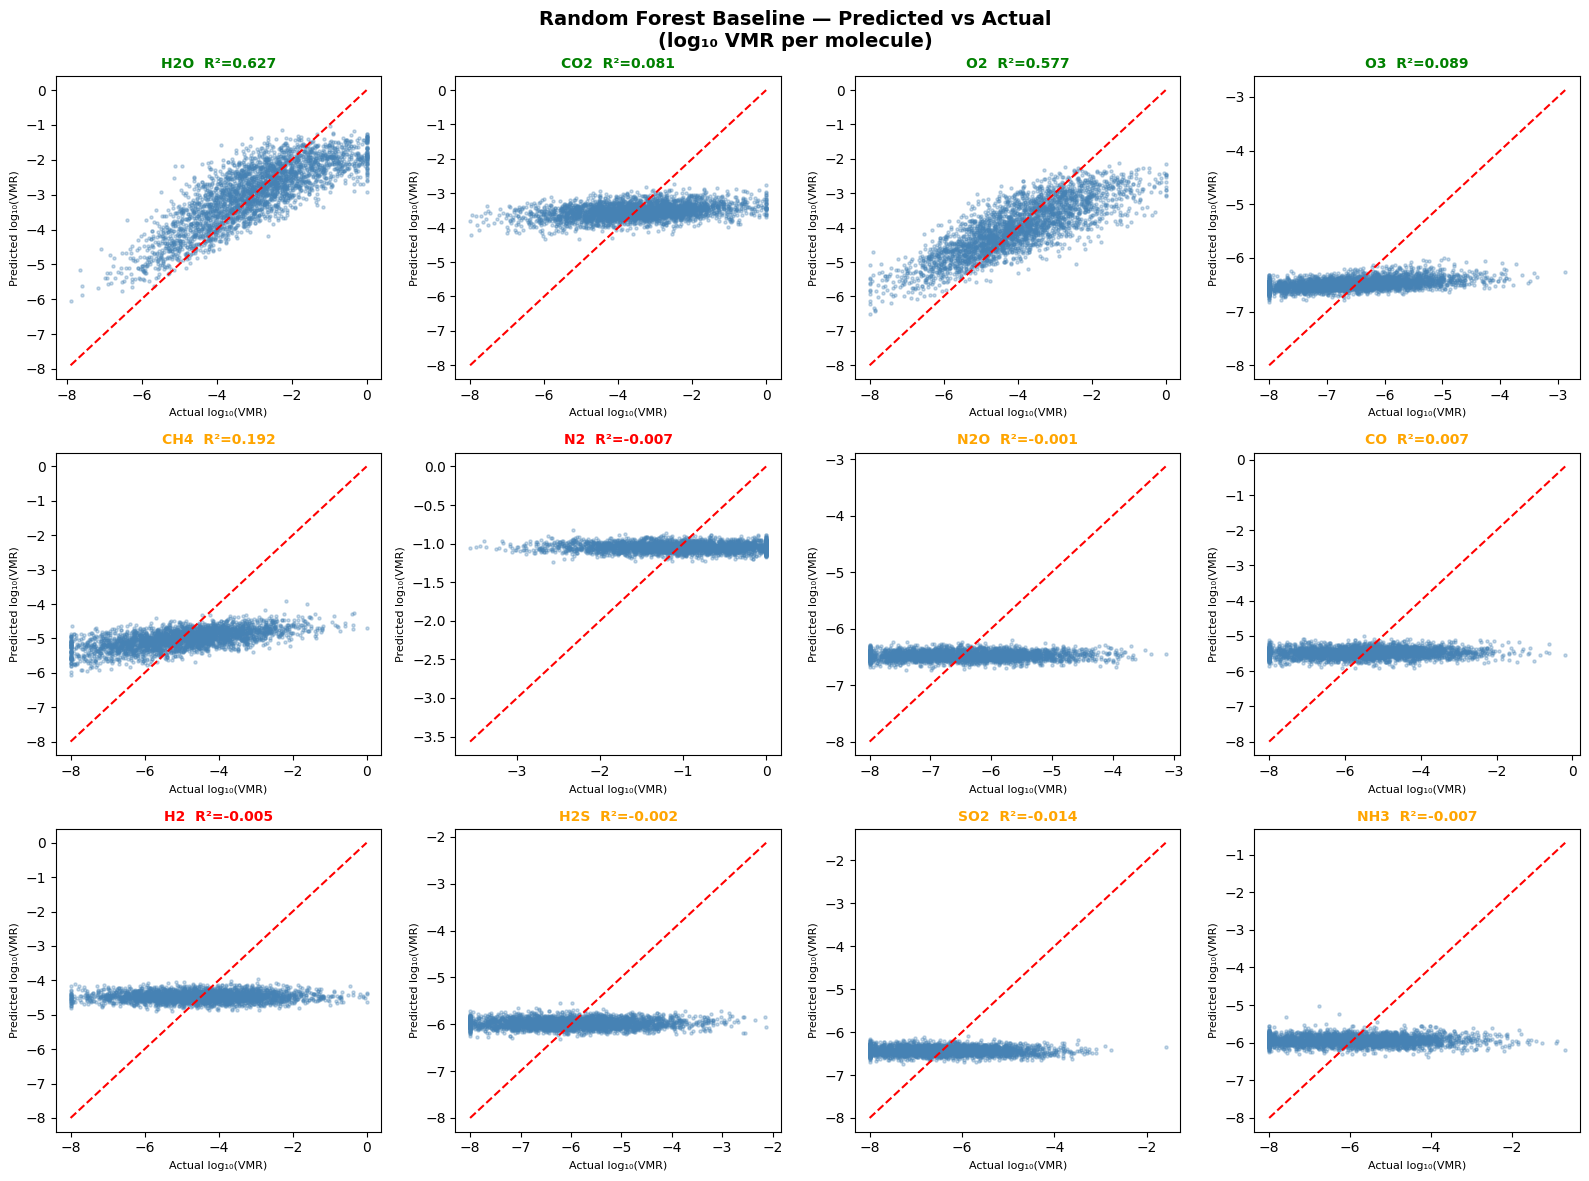

Plot saved to results/plots/rf_baseline_results.png ✓


In [8]:
# Cell 8 - Visualize Results
os.makedirs('../results/plots', exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Random Forest Baseline — Predicted vs Actual\n(log₁₀ VMR per molecule)',
             fontsize=14, fontweight='bold')

for i, (mol, ax) in enumerate(zip(MOLECULES, axes.ravel())):
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.3, s=5, color='steelblue')
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    
    if mol in STRONG_FEATURES:
        color = 'green'
    elif mol in WEAK_FEATURES:
        color = 'red'
    else:
        color = 'orange'
        
    ax.set_title(f'{mol}  R²={r2_list[i]:.3f}', 
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Actual log₁₀(VMR)', fontsize=8)
    ax.set_ylabel('Predicted log₁₀(VMR)', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/rf_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/plots/rf_baseline_results.png ✓")

In [3]:
# Cell 9 - Summary & Key Findings (hardcoded results)
print("="*65)
print("EXPERIMENT 1: RANDOM FOREST BASELINE SUMMARY")
print("="*65)
print(f"\nDataset: INARA synthetic (generated via download_inara.py)")
print(f"Total samples:    20,000")
print(f"Training samples: 14,000  (70%)")
print(f"Val samples:      3,000  (15%)")
print(f"Test samples:     3,000  (15%)")
print(f"\nModel: RandomForestRegressor")
print(f"  n_estimators : 100")
print(f"  max_depth    : 15")
print(f"  Features used: Ch0 (SNR) + Ch1 (Mean-Sub) + Aux = 8764")
print(f"\nPer-Molecule Results:")
print(f"  {'Molecule':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print(f"  {'-'*36}")
results = [
    ('H2O', 0.886, 0.711, 0.627),
    ('CO2', 1.386, 1.105, 0.081),
    ('O2',  0.957, 0.757, 0.577),
    ('O3',  0.891, 0.731, 0.089),
    ('CH4', 1.328, 1.068, 0.192),
    ('N2',  0.738, 0.612,-0.007),
    ('N2O', 0.955, 0.776,-0.001),
    ('CO',  1.433, 1.154, 0.007),
    ('H2',  1.456, 1.161,-0.005),
    ('H2S', 1.146, 0.933,-0.002),
    ('SO2', 1.084, 0.887,-0.014),
    ('NH3', 1.396, 1.145,-0.007),
]
for mol, rmse, mae, r2 in results:
    print(f"  {mol:<8} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}")
print(f"  {'-'*36}")
print(f"  {'MEAN':<8} {1.138:>8.3f} {0.920:>8.3f} {0.128:>8.3f}")
print(f"\nKey Findings:")
print(f"  Best  : H2O (R²=0.627), O2 (R²=0.577)")
print(f"  Worst : H2  (R²=-0.005), N2 (R²=-0.007)")
print(f"  Mean R²=0.128 — baseline established")
print("="*65)

EXPERIMENT 1: RANDOM FOREST BASELINE SUMMARY

Dataset: INARA synthetic (generated via download_inara.py)
Total samples:    20,000
Training samples: 14,000  (70%)
Val samples:      3,000  (15%)
Test samples:     3,000  (15%)

Model: RandomForestRegressor
  n_estimators : 100
  max_depth    : 15
  Features used: Ch0 (SNR) + Ch1 (Mean-Sub) + Aux = 8764

Per-Molecule Results:
  Molecule     RMSE      MAE       R2
  ------------------------------------
  H2O         0.886    0.711    0.627
  CO2         1.386    1.105    0.081
  O2          0.957    0.757    0.577
  O3          0.891    0.731    0.089
  CH4         1.328    1.068    0.192
  N2          0.738    0.612   -0.007
  N2O         0.955    0.776   -0.001
  CO          1.433    1.154    0.007
  H2          1.456    1.161   -0.005
  H2S         1.146    0.933   -0.002
  SO2         1.084    0.887   -0.014
  NH3         1.396    1.145   -0.007
  ------------------------------------
  MEAN        1.138    0.920    0.128

Key Findings:
